Authors:
- Iria Janeiro Pazos.
- Laura González Lemos.

In [1]:
import random
random.seed(1234)

In [2]:
# Download dataset
import tensorflow as tf
import tensorflow_datasets as tfds

raw_train_data, train_info = tfds.load('stl10', split='train', as_supervised=True, with_info=True) # tuple (image, label)
raw_test_data, test_info = tfds.load('stl10', split='test', as_supervised=True, with_info=True) # tuple (image, label)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

...

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/stl10/incomplete.2HAFCF_1.0.0/stl10-test.tfrecord*...:   0%|          | 0/…

Generating unlabelled examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/stl10/incomplete.2HAFCF_1.0.0/stl10-unlabelled.tfrecord*...:   0%|        …

Dataset stl10 downloaded and prepared to /root/tensorflow_datasets/stl10/1.0.0. Subsequent calls will reuse this data.


Number of classes: 10
Classes names: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']

Features shape: (96, 96, 3)
Features dtype: <dtype: 'uint8'>


,image,label
0,,1 (bird)
1,,0 (airplane)
2,,8 (ship)
3,,3 (cat)

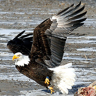
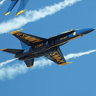
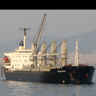
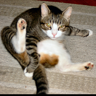

In [3]:
# Check train data
print('Number of classes:', train_info.features["label"].num_classes)
print('Classes names:', train_info.features["label"].names)
print()
print('Features shape:', train_info.features["image"].shape)
print('Features dtype:', train_info.features["image"].dtype)


tfds.as_dataframe(raw_train_data.take(4), train_info)


Number of classes: 10
Classes names: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']

Features shape: (96, 96, 3)
Features dtype: <dtype: 'uint8'>


,image,label
0,,9 (truck)
1,,3 (cat)
2,,3 (cat)
3,,1 (bird)

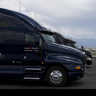
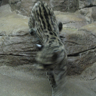
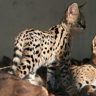
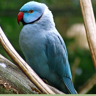

In [4]:
# Check test data
print('Number of classes:', test_info.features["label"].num_classes)
print('Classes names:', test_info.features["label"].names)
print()
print('Features shape:', test_info.features["image"].shape)
print('Features dtype:', test_info.features["image"].dtype)

tfds.as_dataframe(raw_test_data.take(4), test_info)

# Data Preprocessing

The first step in the project is to preprocess the data. We perform the following transformations:
- Image size normalization: We resize all images to a common size to ensure consistency in the input data.
- One hot encoding: We convert categorical labels into a binary format that can be used by machine learning algorithms.

In [5]:
# Preprocessing

def preprocess(image, label, train_info=train_info):
    # Rescale the image (normalize)
    image = tf.cast(image, tf.float32) / 255.0

    # One-hot encode the labels
    num_classes = train_info.features["label"].num_classes
    label = tf.one_hot(label, depth=num_classes)

    return image, label

prep_train_data = raw_train_data.map(preprocess)
test_data = raw_test_data.map(preprocess)

Secondly, we split the dataset into training and validation sets (80% training, 20% validation). A test split is not needed as the dataset already provides a seperate test set.

In [11]:
# Train-Validation split (80-20)
prep_train_data = prep_train_data.shuffle(1000)

num_samples = train_info.splits['train'].num_examples
train_size = int(0.8 * num_samples)

train_data = prep_train_data.take(train_size)
val_data = prep_train_data.skip(train_size)

In [12]:
BATCH_SIZE = 32 # You can adjust this based on your GPU memory

# 1. Batch the training data and use prefetch for speed
# We shuffle again here to ensure randomness within the batches
train_data = train_data.shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# 2. Batch the validation data
val_data = val_data.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# 3. Batch the test data (if you plan to evaluate later)
test_data = test_data.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [18]:
from tensorflow.keras import layers, models, regularizers


def residual_block(x, filters, stride=1):
    shortcut = x
    
    # First convolution in the block
    x = layers.Conv2D(filters, (3, 3), strides=stride, padding='same', 
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    
    # Second convolution
    x = layers.Conv2D(filters, (3, 3), strides=1, padding='same',
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    
    # If dimensions changed (due to stride), adjust the shortcut connection
    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, (1, 1), strides=stride, padding='same')(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)
        
    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)
    return x

def build_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    
    # 1. Data Augmentation (Internal to the model for simplicity)
    x = layers.RandomFlip("horizontal")(inputs)
    x = layers.RandomRotation(0.1)(x)
    
    # 2. Initial Convolutional Layer
    x = layers.Conv2D(32, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    
    # 3. Stacked Residual Blocks (Increasing complexity)
    x = residual_block(x, 64, stride=2) # Downsample to 1/2 size
    x = residual_block(x, 64)
    x = layers.Dropout(0.5)(x)
    
    x = residual_block(x, 128, stride=2) # Downsample to 1/4 size
    x = residual_block(x, 128)
    
    # 4. Global Average Pooling (Regularizes and reduces parameters)
    x = layers.GlobalAveragePooling2D()(x)
    
    # 5. Output Layer
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    return models.Model(inputs, outputs)

# Extract info for initialization
img_shape = train_info.features['image'].shape
num_classes = train_info.features['label'].num_classes

model = build_model(img_shape, num_classes)

In [21]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy', # Used because labels are one-hot encoded
    metrics=['accuracy']
)

# Callbacks for tuning
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.2, patience=5)
]

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=50,
    callbacks=callbacks
)

Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 27s 130ms/step - accuracy: 0.4366 - loss: 1.5820 - val_accuracy: 0.3680 - val_loss: 1.6764 - learning_rate: 1.0000e-04
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 16s 120ms/step - accuracy: 0.4463 - loss: 1.5864 - val_accuracy: 0.3720 - val_loss: 1.6936 - learning_rate: 1.0000e-04
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 18s 138ms/step - accuracy: 0.4514 - loss: 1.5536 - val_accuracy: 0.3620 - val_loss: 1.7181 - learning_rate: 1.0000e-04
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 16s 117ms/step - accuracy: 0.4705 - loss: 1.5251 - val_accuracy: 0.3620 - val_loss: 1.6969 - learning_rate: 1.0000e-04
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 16s 119ms/step - accuracy: 0.4641 - loss: 1.5096 - val_accuracy: 0.4130 - val_loss: 1.6096 - learning_rate: 1.0000e-04
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 17s 125ms/step - accuracy: 0.4830 - loss: 1.5070 - val_accuracy: 0.4380 - val_loss: 1.5851 - learning_rate: 1.0000e-04
Epoch 7/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 16s 11